In [1]:
import sleap
import sys
import cmath

sys.path.append('..')
from python.polygon_based_correction import *
from eval.eval import *

## load points

In [2]:
single_model_points_path = '/home/mingxiao/Desktop/jellyfish/label/predictions/single_model_all_tracked_points.npy'
single_model_points = np.load(single_model_points_path)
print(single_model_points.shape)

(3240000, 17, 2)


## eval original output

In [3]:
(np.isnan(single_model_points).sum()) # missing points are nan

109014

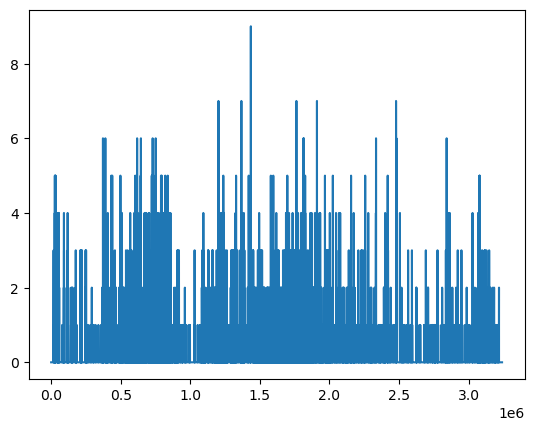

In [4]:
missing_cnt_by_frames = np.isnan(single_model_points).sum(axis=(1, 2)) / 2
plt.plot(missing_cnt_by_frames[:])
plt.show()

In [5]:
np.mean(missing_cnt_by_frames[missing_cnt_by_frames > 0])

1.5025636784651009

In [6]:
len(missing_cnt_by_frames[missing_cnt_by_frames > 0])

36276

## correction functions

**Assumption**: all predicted points are correct (not mispredicted at where there isn't a tentacle bulb) -> no detection of mispredictions


What this part does:
1. Linearly interpolate missing points using polar coordinates 
2. Assign ID based on polygon reconstruction

In [8]:
def assign_id_to_points(all_tracked_points, frame_idx, polygon_constructor=poly_4):
    curr_frame_pts = all_tracked_points[frame_idx].copy()
    pt_cnt = len(curr_frame_pts)
    non_missing_mask = np.isnan(curr_frame_pts).sum(axis=1) == 0 # 1 = non-missing, 0 = missing
    
    # if non_missing_mask.sum() == pt_cnt:
    #     assign_id_to_points_non_missing(all_tracked_points, frame_idx, polygon_constructor)
    #     return
    
    # curr_id_mapping = [None for _ in range(pt_cnt)]
    # prev_frame_pts = all_tracked_points[frame_idx-1]
    
    # # for non-missing points, assign id based on nearest neighbor in previous frame
    # matching_queue = [] # (dist, pt_idx, sorted_idx)
    # updated_non_missing_mask = np.zeros_like(non_missing_mask)
    # for pt_idx in range(len(curr_frame_pts)):
    #     if not non_missing_mask[pt_idx]:
    #         continue
    #     dists = ((curr_frame_pts[pt_idx] - prev_frame_pts)**2).sum(axis=1)
    #     dists_sorted_idx = np.argmin(dists)
    #     # if the closest neighbor is too far away, this point may be mispredicted?
    #     matching_queue.append((dists[dists_sorted_idx], pt_idx, dists_sorted_idx))
    
    # matching_queue.sort(key=lambda x: x[0])
    
    # for _, pt_idx, sorted_idx in matching_queue:
    #     if sorted_idx not in curr_id_mapping:
    #         curr_id_mapping[pt_idx] = sorted_idx
    #         all_tracked_points[frame_idx][sorted_idx] = curr_frame_pts[pt_idx]
    #         updated_non_missing_mask[sorted_idx] = 1
    
    # for missing points, interpolate from its two neighbors using polar coordinates
    polar_interpolated_pts = polar_interpolate(all_tracked_points[frame_idx], non_missing_mask)
    for pt_idx in range(pt_cnt):
        if non_missing_mask[pt_idx]:
            continue
        all_tracked_points[frame_idx][pt_idx] = polar_interpolated_pts[pt_idx]
    
    # assign order again to ensure maximal global alignment
    assign_id_to_points_non_missing(all_tracked_points, frame_idx, polygon_constructor)
        
def assign_id_to_points_non_missing(all_tracked_points, frame_idx, polygon_constructor=poly_4):
    curr_frame_pts = all_tracked_points[frame_idx]
    polygon_order = polygon_constructor(curr_frame_pts)
    best_shift = find_best_roll(curr_frame_pts[polygon_order], all_tracked_points[frame_idx-1])
    shifted_indices = np.roll(polygon_order, best_shift, axis=0)
    all_tracked_points[frame_idx] = curr_frame_pts[shifted_indices]

def polygon_correction_with_points(all_tracked_points, polygon_constructor=poly_4, return_indices=False):

    frame_cnt = all_tracked_points.shape[0]
    corrected_coords = all_tracked_points.copy()

    for frame_idx in range(1, frame_cnt):
        assign_id_to_points(corrected_coords, frame_idx, polygon_constructor)

    return corrected_coords

In [ ]:
single_model_points_corrected = polygon_correction_with_points(single_model_points)

In [2]:
single_model_points_corrected_path = '/home/mingxiao/Desktop/jellyfish/label/predictions/single_model_all_tracked_points_corrected.npy'
single_model_points_corrected = np.load(single_model_points_corrected_path)
print(single_model_points_corrected.shape)

(3240000, 17, 2)


In [3]:
single_model_points_corrected_eval_path = '/home/mingxiao/Desktop/jellyfish/label/predictions/single_model_all_tracked_points_corrected_eval.npy'

In [4]:
eval_dataset_from_points(single_model_points_corrected, method='polygon', save_path=single_model_points_corrected_eval_path)

KeyboardInterrupt: 